Example for the deconvolution in the fitting method of pyspectrum, 
this can be later improved by better fitting proccedure

In [1]:
from pyspectrum.core import Spectrum, Domain
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration
from pyspectrum.calibration.detector_calibration import DetectorCalibration
from pyspectrum.identification import Convolution
from pyspectrum.identification.snr import SNRFinder
from pyspectrum.identification.kernels.mexican_hat import gaussian_2_dev

from pyspectrum.domain_fitting.sum_of_gaussians import SumOfGaussians
from pyspectrum.domain_fitting.sum_of_gaussians_erf import SumOfGaussiansErf
from pyspectrum.domain_analysis.find_peaks import find_domain_peaks
from pyspectrum.domain_analysis.background import domain_erf_background
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, nominal_value, std_dev

# Loading a new spectrum
The spectrum is of Eu152, and there was not calibration yet.

In [2]:
path = '../Library/152Eu_calsource_10cm_85ks.txt'
spectrum = pd.read_csv(path, names=['counts'])
spectrum['channel'] = spectrum.index 

axis_calibration = AxisCalibration(np.poly1d([0.29239695, 7.10512435]), "energy")

spectrum = Spectrum.from_dataframe(spectrum,
                                   axis_calib=axis_calibration)

domains = [(383, 403), (1140,1165), (1485, 1505), (2627, 2650), (3260,3285), (4770, 4810)]
energies = [121.78, 344.28, 443.96, 778.9, 964.08, 1408]

calib = DetectorCalibration(spectrum=spectrum, peak_domains=domains, known_axis_values=energies)
energy_calibration, resolution_calibration = calib.generate()
spectrum.set_axis_calibration(energy_calibration)
spectrum.set_resolution_calibration(resolution_calibration)

overLap = spectrum.domain(start_val=1436, stop_val=1470)
subtracted_overlap = overLap.subtract_background(domain_erf_background(overLap))

## Slice of overlapping peaks which i want to deconvolute using fitting

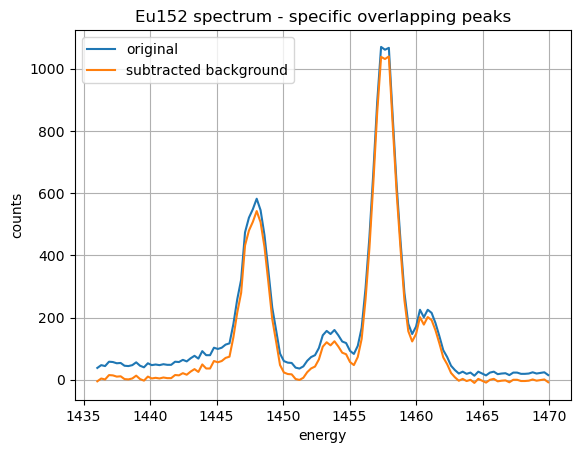

In [3]:
overLap.data.plot(label="original")
subtracted_overlap.data.plot(label="subtracted background")

plt.title('Eu152 spectrum - specific overlapping peaks')
plt.xlabel('energy')
plt.ylabel('counts')
plt.grid(True, which='both')
plt.legend()

## fitting for deconvolution

In [4]:
gf = SumOfGaussians()
peaks, propt = find_domain_peaks(subtracted_overlap, prominence=20)

In [5]:
fit_parm = gf.fit(domain=subtracted_overlap, prominence=20)
fit_values = gf.evaluate(subtracted_overlap.axis, fit_result=fit_parm)

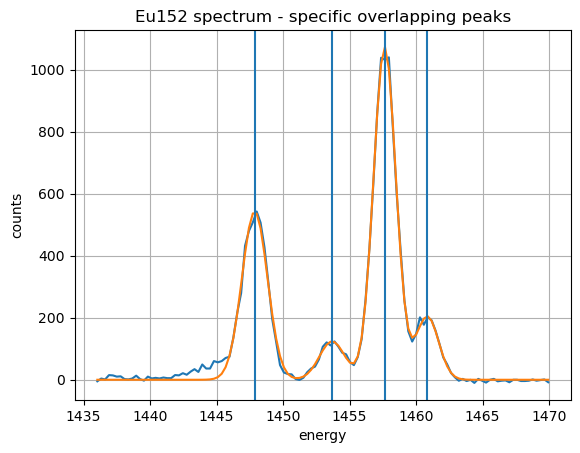

In [6]:
subtracted_overlap.data.plot()
plt.plot(subtracted_overlap.axis, fit_values)
plt.grid(True, which='both')
plt.title('Eu152 spectrum - specific overlapping peaks')
plt.xlabel('energy')
plt.ylabel('counts')

for i in range(4):
    plt.axvline(x=fit_parm['center'][i])

you can use the fitter to estimate the fit standard deviation

In [7]:
sample_size = 1000
fit_dist = np.zeros((sample_size, len(subtracted_overlap.axis)))
rand_parms = np.random.multivariate_normal(fit_parm['flat_mean'].values, fit_parm['covariance'].values, size=sample_size)
for i in range(sample_size):
    fit_dist[i, :] = gf.flat_evaluate(subtracted_overlap.axis, *rand_parms[i,:])

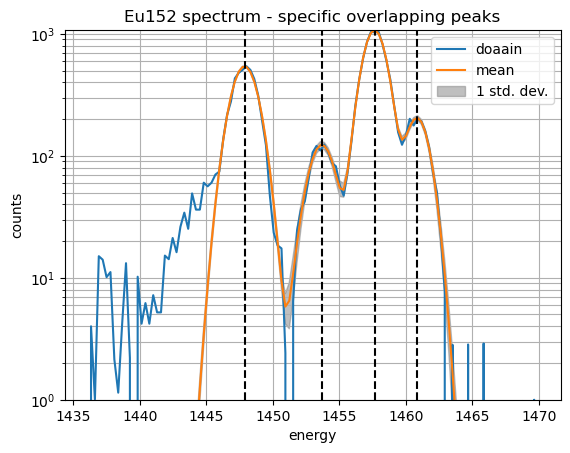

In [13]:
mean_fit = fit_dist.mean(axis=0)
std_fit = fit_dist.std(axis=0)

subtracted_overlap.data.plot(yscale='log', label='doaain')
plt.plot(subtracted_overlap.axis, mean_fit, label='mean')
plt.fill_between(subtracted_overlap.axis,
                 y1=mean_fit+std_fit,
                y2=mean_fit-std_fit,
                 alpha=0.5, color='gray', label='1 std. dev.')

plt.grid(True, which='both')
plt.title('Eu152 spectrum - specific overlapping peaks')
plt.xlabel('energy')
plt.ylabel('counts')
plt.ylim([1, mean_fit.max()])
plt.legend()
for i in range(4):
    plt.axvline(x=fit_parm['center'][i], color='black', ls='--')